## explore age groups

In [ ]:
# necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

In [ ]:
# read the data integrated in Script: Data_read.ipynb
schema = {
    "Age": pl.Utf8
}

raw_data = pl.read_csv("Data/SDBII_5.csv" , schema_overrides=schema)

raw_data  = raw_data .with_columns(
    pl.col("ts").str.to_datetime()
)

raw_data  = raw_data .with_columns(
    pl.col("PtID").cast(pl.Categorical)
)

raw_data_sorted = raw_data .sort(["PtID", "ts"])
raw_data_sorted = raw_data_sorted.unique(subset=["PtID", "ts"], keep="first")

raw_data_pd = raw_data_sorted.to_pandas()

In [ ]:
raw_data_pd["Age"].unique()

array(['37', '34', '36', '65', '18', '22', '61', '68.0', '44', '38', '53',
       '17', '2', '27', '25', '45', '35', '70', '48', '5', '65.0', '4',
       '28', '29.40000000000009', '19', '26', '64', '29', '40', '66.0',
       '3', '15', '7', '39', '13', '21', '24', '6', '56', '11', '47',
       '67.0', '63.0', '54', '43', '32', '65 - 74 yrs', '50', '42', '12',
       '41', '66', '63', '30', '10', '69.0', '58', '57', '31', '49',
       '71.0', '62', '64.0', '16', '55', '60', '52', '68', '74.0', '8',
       '72.0', '46', '14', '80.0', '59', '23', '67', '9', '51', '81.0',
       '78.0', '36.0', '33', '76', '78', '71', '20', '62.0', '61.0', '73',
       '28.40000000000009', '61.799999999999955', '60-100', '76.0', '69',
       '60.0', '37.0', '75.0', '70.0', '79.0', '82.0',
       '32.90000000000009', '83.0', '72', '22.200000000000045',
       '35 - 44 yrs', '77.0', '75', '77', '86.0', '74',
       '27.40000000000009', '31.90000000000009', '84.0', '79', '73.0',
       '29.90000000000009', '

In [ ]:
result = raw_data_pd[["GlucoseCGM", "Age", "PtID"]]
result["Age"] = pd.to_numeric(result["Age"], errors="coerce")
result = result.dropna(subset=["Age"])     # remove rows where conversion failed
result["Age"] = result["Age"].astype(int)


children_df = result[result["Age"] < 11]
youth_df = result[result["Age"].between(11, 19)]
young_adults_df = result[result["Age"].between(19, 26)]
adults_df = result[result["Age"].between(26, 51)]
elderly_df = result[result["Age"] > 51]

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_19282/289711712.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Age'] = pd.to_numeric(result['Age'], errors='coerce')


In [4]:
result["PtID"].nunique()

2282

## Visual Inspection

<Axes: xlabel='Age', ylabel='GlucoseCGM'>

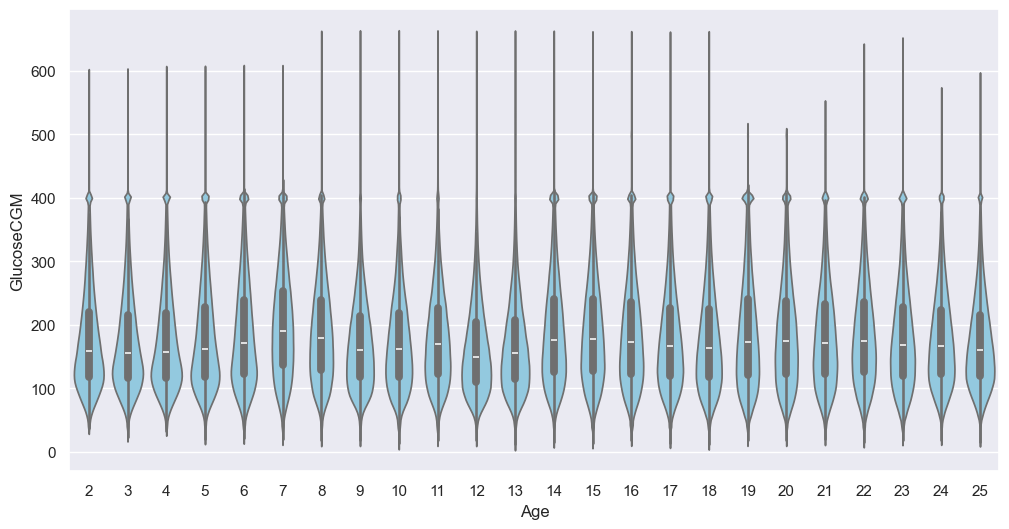

In [ ]:
child_df = result[result["Age"] < 26]

sns.set_theme(rc={"figure.figsize": (12, 6)})
sns.violinplot(x="Age", y="GlucoseCGM", data=child_df, color="skyblue")

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3283/2752570028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Age'] = pd.to_numeric(result['Age'], errors='coerce')


<Axes: xlabel='Age', ylabel='GlucoseCGM'>

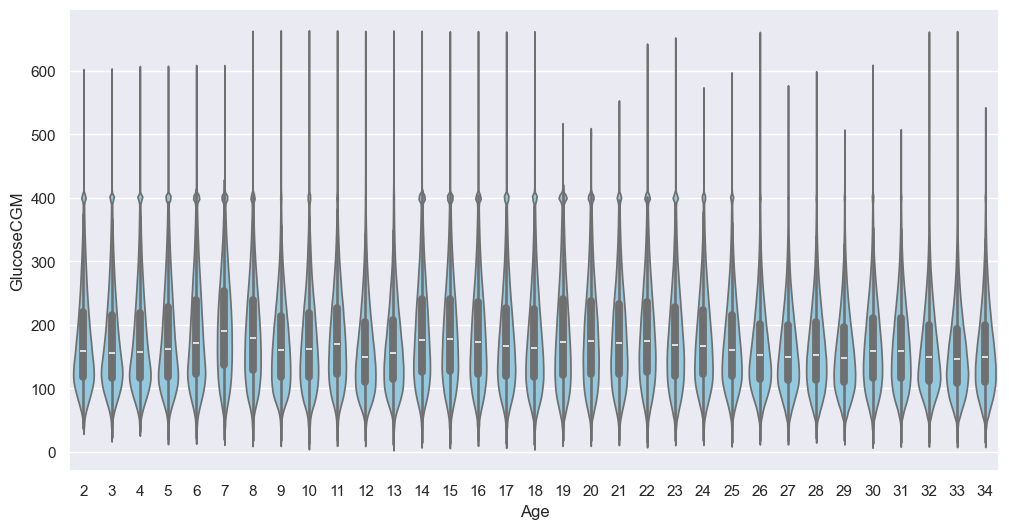

In [ ]:
result = raw_data_pd[["GlucoseCGM", "Age", "PtID"]]
result["Age"] = pd.to_numeric(result["Age"], errors="coerce")
result = result.dropna(subset=["Age"])  
result["Age"] = result["Age"].astype(int)


youth_df = result[result["Age"] < 35]

sns.set_theme(rc={"figure.figsize": (12, 6)})
sns.violinplot(x="Age", y="GlucoseCGM", data=youth_df, color="skyblue")

<Axes: xlabel='Age', ylabel='GlucoseCGM'>

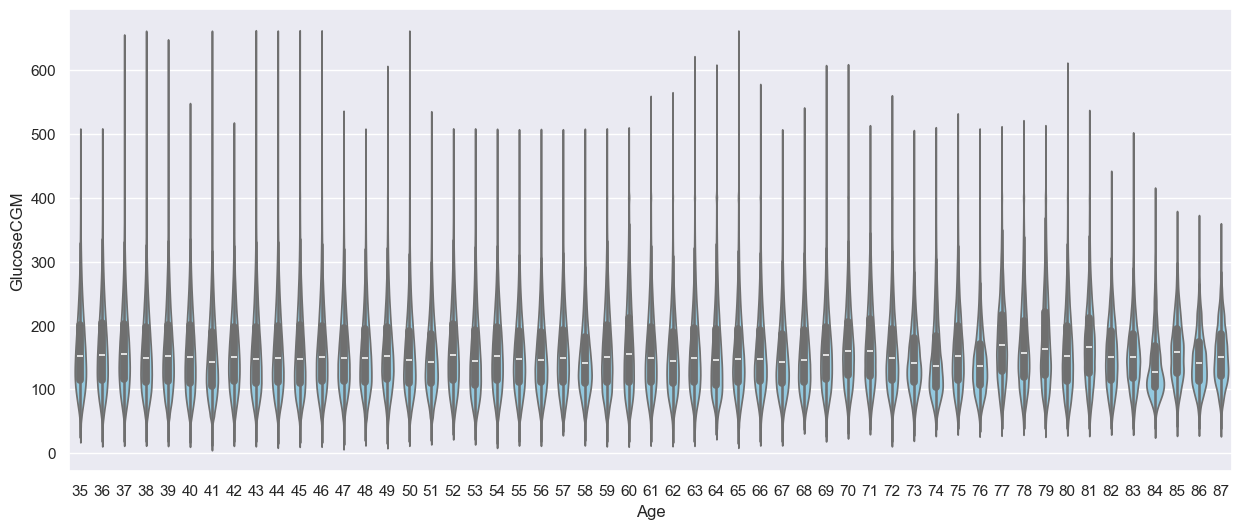

In [ ]:
adults_df = result[result["Age"] > 34]

sns.set_theme(rc={"figure.figsize": (15, 6)})
sns.violinplot(x="Age", y="GlucoseCGM", data=adults_df, color="skyblue")

<Axes: xlabel='Age', ylabel='GlucoseCGM'>

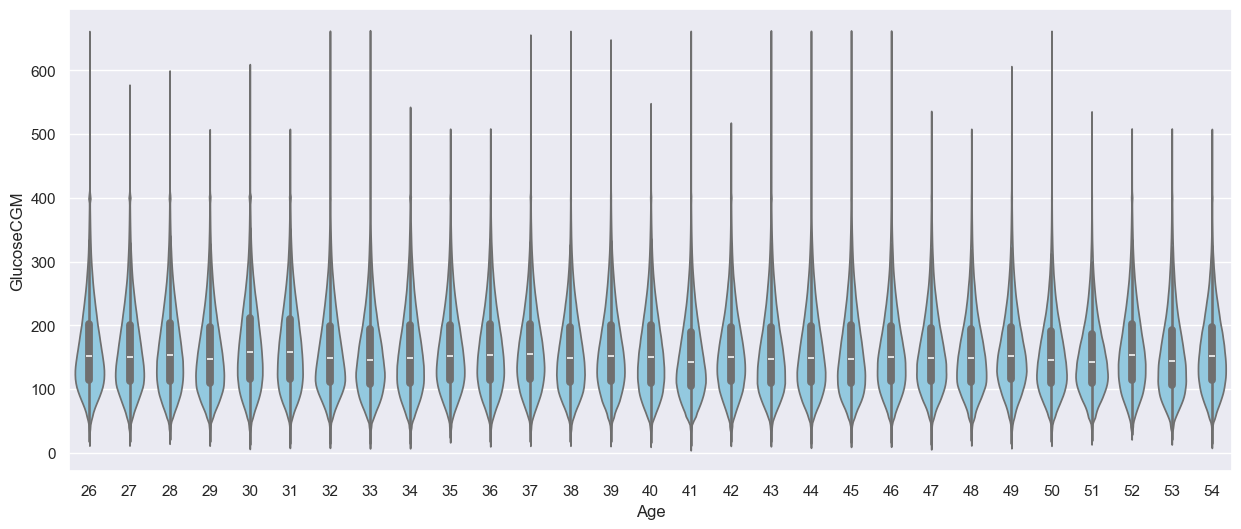

In [ ]:
adults_df = result[(result["Age"] > 25) & (result["Age"] < 55)]

sns.set_theme(rc={"figure.figsize": (15, 6)})
sns.violinplot(x="Age", y="GlucoseCGM", data=adults_df, color="skyblue")

<Axes: xlabel='Age', ylabel='GlucoseCGM'>

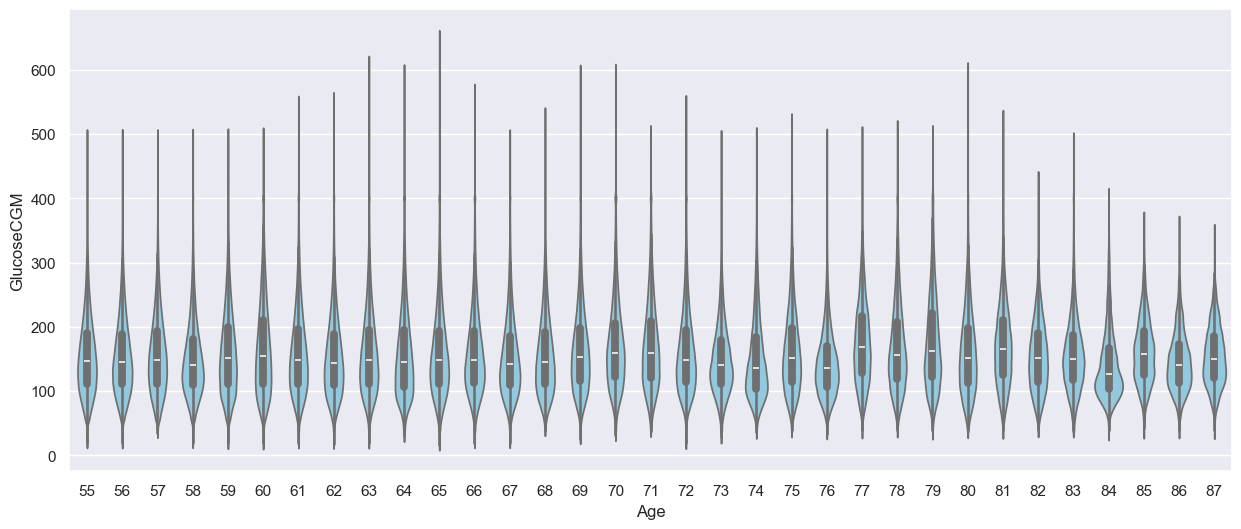

In [ ]:
adults_df = result[result["Age"] > 54]

sns.set_theme(rc={"figure.figsize": (15, 6)})
sns.violinplot(x="Age", y="GlucoseCGM", data=adults_df, color="skyblue")

In [ ]:
result = raw_data_pd[["GlucoseCGM", "Age", "PtID"]]
result["Age"] = pd.to_numeric(result["Age"], errors="coerce")
result = result.dropna(subset=["Age"])     # remove rows where conversion failed
result["Age"] = result["Age"].astype(int)
result = result.dropna(subset=["GlucoseCGM"]) 

df = result.copy()
group_0_5 = df[(df["Age"] >= 0) & (df["Age"] <= 5)]
group_0_8 = df[(df["Age"] >= 0) & (df["Age"] <= 8)]
group_0_10 = df[(df["Age"] >= 0) & (df["Age"] <= 10)]
group_0_13 = df[(df["Age"] >= 0) & (df["Age"] <= 13)]

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3283/3862980134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Age'] = pd.to_numeric(result['Age'], errors='coerce')


In [ ]:
def variation_stats(data, label):
    data = data.dropna(subset=["GlucoseCGM"]) 
    hr = data["GlucoseCGM"]
    variance = np.var(hr, ddof=1)          # sample variance
    std_dev = np.std(hr, ddof=1)           # sample std dev
    cv = std_dev / np.mean(hr) * 100       # coefficient of variation (%)
    print(f"\n📈 {label}")
    print(f"Variance: {variance:.4f}")
    print(f"Std Dev: {std_dev:.4f}")
    print(f"Coefficient of Variation: {cv:.4f}%")
    return variance, std_dev, cv
 
# Compute stats for both groups
var_5, sd_5, cv_5 = variation_stats(group_0_5, "Age 0–5")
var_18, sd_18, cv_18 = variation_stats(group_0_8, "Age 0–8")
var_10, sd_10, cv_10 = variation_stats(group_0_10, "Age 0–10")
var_13, sd_13, cv_13 = variation_stats(group_0_13, "Age 0–13")


📈 Age 0–5
Variance: 5999.0289
Std Dev: 77.4534
Coefficient of Variation: 44.1553%

📈 Age 0–8
Variance: 6273.3019
Std Dev: 79.2042
Coefficient of Variation: 43.7987%

📈 Age 0–10
Variance: 6208.6509
Std Dev: 78.7950
Coefficient of Variation: 43.7201%

📈 Age 0–13
Variance: 6110.8192
Std Dev: 78.1717
Coefficient of Variation: 43.6991%


In [ ]:
def stats_for_range(df, a, b):
    x = pd.to_numeric(df.loc[df["Age"].between(a, b), "GlucoseCGM"], errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "min": x.min(), "max": x.max(),
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "var": x.var(ddof=1),
        "cv_%": x.std(ddof=1) / x.mean() * 100,
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "MAD": (x - x.median()).abs().median()
    })

s_0_5  = stats_for_range(df, 0, 5)
s_0_8 = stats_for_range(df, 0, 8)
s_0_10  = stats_for_range(df, 0, 10)
s_0_13 = stats_for_range(df, 0, 13)
s_0_15 = stats_for_range(df, 8, 15)
s_0_155 = stats_for_range(df, 10, 15)
s_0_25 = stats_for_range(df, 10, 25)
s_0_255 = stats_for_range(df, 15, 25)

print("0–5\n", s_0_5.round(2))
print("0–8\n", s_0_8.round(2))
print("0–10\n", s_0_10.round(2))
print("\n0–13\n", s_0_13.round(2))
print("\n8-15\n", s_0_15.round(2))
print("\n10–15\n", s_0_155.round(2))
print("\n10–25\n", s_0_25.round(2))
print("\n15–25\n", s_0_255.round(2))

0–5
 n       10675029.00
min           20.00
max          600.00
mean         175.41
std           77.45
var         5999.03
cv_%          44.16
IQR          104.00
MAD           48.00
dtype: float64
0–8
 n       15886258.00
min           18.00
max          654.00
mean         180.84
std           79.20
var         6273.30
cv_%          43.80
IQR          109.00
MAD           52.00
dtype: float64
0–10
 n       17228077.00
min           14.00
max          654.00
mean         180.23
std           78.79
var         6208.65
cv_%          43.72
IQR          108.00
MAD           52.00
dtype: float64

0–13
 n       19837509.00
min           12.00
max          654.00
mean         178.89
std           78.17
var         6110.82
cv_%          43.70
IQR          107.00
MAD           51.00
dtype: float64

8-15
 n       10161417.00
min           12.00
max          654.00
mean         182.41
std           78.93
var         6230.50
cv_%          43.27
IQR          108.00
MAD           52.00
dtype: flo

In [17]:
s_0_14 = stats_for_range(df, 0, 14)

print("0–14\n", s_0_14.round(2))

0–14
 n       21623767.00
min           12.00
max          654.00
mean         179.80
std           78.60
var         6177.32
cv_%          43.71
IQR          107.00
MAD           51.00
dtype: float64


In [ ]:
for df in [children_df,youth_df,young_adults_df,adults_df,elderly_df]:
    df = df.dropna(subset=["GlucoseCGM"])  
    print(df["PtID"].nunique())
    print(df["GlucoseCGM"].count())

    subject_counts = df.groupby("PtID").size().reset_index(name="GlucoseCGM_count")
    # Sort in descending order
    top10_subjects = subject_counts.sort_values("GlucoseCGM_count", ascending=False).head(10)
    # Print result
    print(top10_subjects)


311
17565607
             PtID  GlucoseCGM_count
1459   73.0_PEDAP            118667
1297   53.0_PEDAP            110035
1059   38.0_PEDAP            109002
1568   87.0_PEDAP            108795
885    28.0_SENCE            108294
1598   90.0_PEDAP            107231
1374   62.0_SENCE            106901
239    13.0_PEDAP            106221
340   143.0_SENCE            105379
1027   36.0_PEDAP            104910
430
18320491
                      PtID  GlucoseCGM_count
2453     Subject3_DiaTrend            397361
2280  LIB194004_T1DGranada            124827
2433    Subject21_DiaTrend            117573
2275  LIB193998_T1DGranada            113858
2302  LIB194028_T1DGranada            108049
2320  LIB194050_T1DGranada            106003
1075             39.0_CITY            105768
191             122.0_CITY            103533
330             142.0_CITY            103504
760              23.0_CITY            102557
289
16060021
                    PtID  GlucoseCGM_count
2464   Subject4_DiaTrend   

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3283/3531870622.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Age', y='GlucoseCGM', data=df, ci=None, estimator='mean')


<Axes: xlabel='Age', ylabel='GlucoseCGM'>

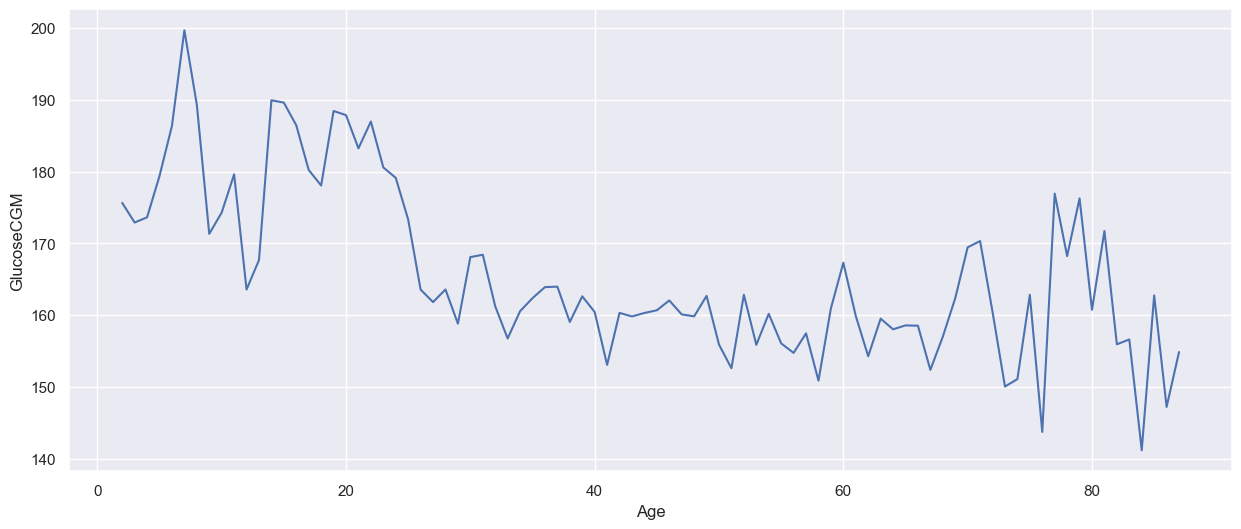

In [ ]:
sns.lineplot(x="Age", y="GlucoseCGM", data=df, errorbar=None, estimator="mean")

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3283/3305869376.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Age', y='GlucoseCGM', data=df, ci=None, estimator='min')


<Axes: xlabel='Age', ylabel='GlucoseCGM'>

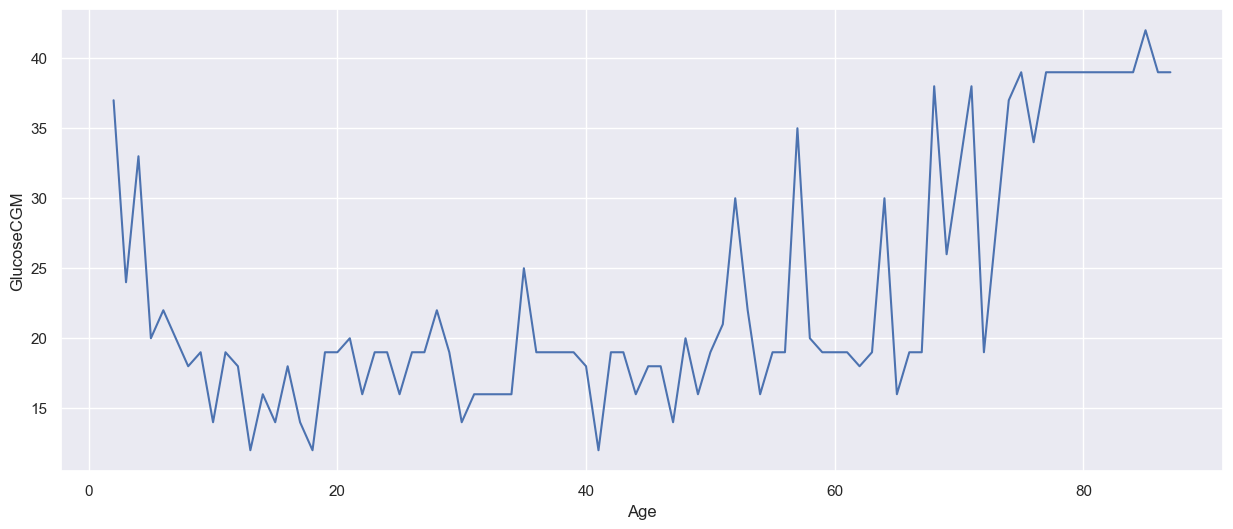

In [ ]:
sns.lineplot(x="Age", y="GlucoseCGM", data=df, ci=None, estimator="min")

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3283/3517880181.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Age', y='GlucoseCGM', data=df, ci=None, estimator='max')


<Axes: xlabel='Age', ylabel='GlucoseCGM'>

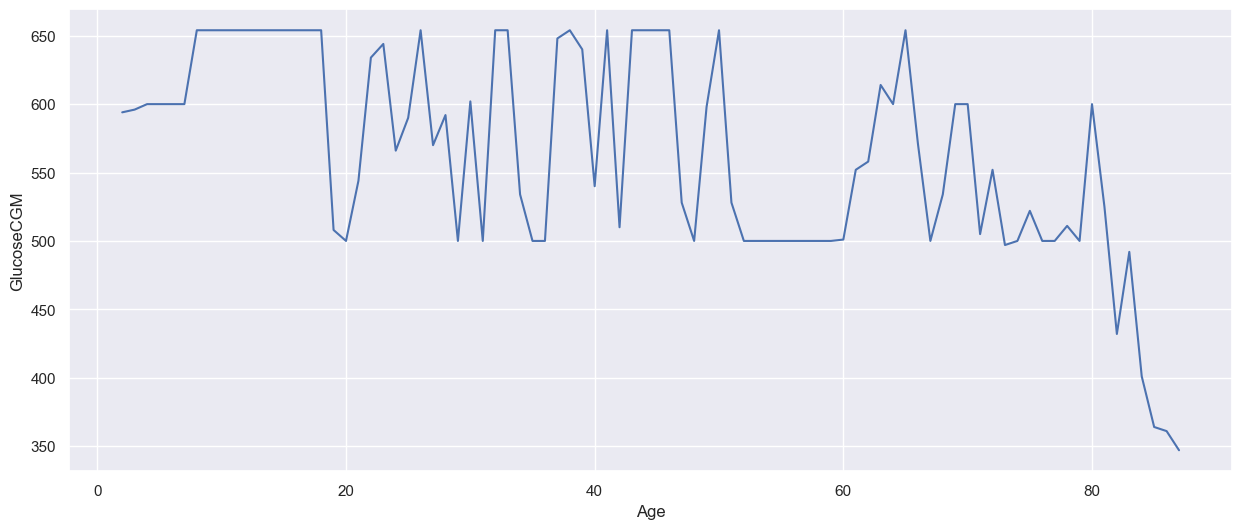

In [ ]:
sns.lineplot(x="Age", y="GlucoseCGM", data=df, ci=None, estimator="max")

## Statistical Analysis

In [ ]:
bins = [0, 8, 14, 24, 51, 100]  # last bin upper bound depends on your data
labels = ["0–7", "8–13", "14–23", "24-50", "51-100"]

# Create new column
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


In [ ]:
groups = [df[df["AgeGroup"] == b]["GlucoseCGM"] for b in df["AgeGroup"].unique()]
f_stat, p_val = stats.f_oneway(*groups)

In [7]:
print(f_stat)

597488.8673767917


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   0–7  14–23    2.965    0.0   2.9013   3.0287   True
   0–7  24-50 -19.4429    0.0 -19.5024 -19.3835   True
   0–7 51-100 -21.5344    0.0 -21.5971 -21.4717   True
   0–7   8–13  -0.1062 0.0133  -0.1976  -0.0148   True
 14–23  24-50 -22.4079    0.0  -22.461 -22.3548   True
 14–23 51-100 -24.4994    0.0 -24.5561 -24.4426   True
 14–23   8–13  -3.0711    0.0  -3.1585  -2.9837   True
 24-50 51-100  -2.0914    0.0  -2.1433  -2.0396   True
 24-50   8–13  19.3368    0.0  19.2524  19.4211   True
51-100   8–13  21.4282    0.0  21.3416  21.5149   True
------------------------------------------------------


In [ ]:
df = result.dropna(subset=["Age"])  
df = df.dropna(subset=["GlucoseCGM"])   
bins = [0, 11, 25, 100]  # last bin upper bound depends on your data
labels = ["0–11", "12–25", "26-100"]

# Create new column
df["AgeGroup1"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup1"] == b]["GlucoseCGM"] for b in df["AgeGroup1"].unique()]
f_stat, p_val = stats.f_oneway(*groups)

tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup1"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–11  12–25    2.021   0.0   1.9702   2.0719   True
  0–11 26-100 -19.9265   0.0  -19.972  -19.881   True
 12–25 26-100 -21.9475   0.0 -21.9862 -21.9089   True
-----------------------------------------------------


In [ ]:

 
bins = [0, 5, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–5", "6–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup1"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup1"] == b]["GlucoseCGM"] for b in df["AgeGroup1"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [43]:
df.groupby("AgeGroup1")["PtID"].nunique()

AgeGroup1
0–5      176
6–15     379
16–25    478
26-50    753
45-90    655
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup1"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   0–5  16–25   6.5392   0.0   6.4659   6.6125   True
   0–5  26-50 -13.9009   0.0 -13.9703 -13.8314   True
   0–5  45-90 -16.6447   0.0  -16.716 -16.5734   True
   0–5   6–15    9.837   0.0    9.757   9.9169   True
 16–25  26-50 -20.4401   0.0 -20.4945 -20.3856   True
 16–25  45-90 -23.1839   0.0 -23.2407 -23.1271   True
 16–25   6–15   3.2978   0.0   3.2304   3.3652   True
 26-50  45-90  -2.7438   0.0  -2.7956  -2.6921   True
 26-50   6–15  23.7378   0.0  23.6746   23.801   True
 45-90   6–15  26.4817   0.0  26.4164  26.5469   True
-----------------------------------------------------


In [ ]:
bins = [0, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–15", "16–25", "25-50", "51-100"]

# Create new column
df["AgeGroup2"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup2"] == b]["GlucoseCGM"] for b in df["AgeGroup2"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup2"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–15  15–25   0.9794   0.0   0.9251   1.0338   True
  0–15  25-50 -19.4606   0.0 -19.5103 -19.4109   True
  0–15 51-100 -22.2044   0.0 -22.2564 -22.1525   True
 15–25  25-50 -20.4401   0.0 -20.4914 -20.3887   True
 15–25 51-100 -23.1839   0.0 -23.2374 -23.1303   True
 25-50 51-100  -2.7438   0.0  -2.7926   -2.695   True
-----------------------------------------------------


In [ ]:
bins = [0, 13, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–13", "14–25", "25-50", "51-100"]

# Create new column
df["AgeGroup3"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup3"] == b]["GlucoseCGM"] for b in df["AgeGroup3"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [45]:
df.groupby("AgeGroup3")["PtID"].nunique()

AgeGroup3
0–13      380
14–25     568
25-50     753
51-100    655
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup3"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–13  15–25   4.4418   0.0    4.387   4.4967   True
  0–13  25-50  -17.376   0.0 -17.4289 -17.3231   True
  0–13 51-100 -20.1198   0.0 -20.1749 -20.0647   True
 15–25  25-50 -21.8178   0.0 -21.8664 -21.7693   True
 15–25 51-100 -24.5617   0.0 -24.6125 -24.5108   True
 25-50 51-100  -2.7438   0.0  -2.7926   -2.695   True
-----------------------------------------------------


In [ ]:
bins = [0, 8, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–8", "9–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup4"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup4"] == b]["GlucoseCGM"] for b in df["AgeGroup4"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup4"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   0–8  16–25   1.1135   0.0   1.0488   1.1783   True
   0–8  26-50 -19.3265   0.0 -19.3869 -19.2661   True
   0–8  45-90 -22.0703   0.0 -22.1328 -22.0079   True
   0–8   9–15     0.38   0.0    0.297    0.463   True
 16–25  26-50 -20.4401   0.0 -20.4946 -20.3855   True
 16–25  45-90 -23.1839   0.0 -23.2407  -23.127   True
 16–25   9–15  -0.7336   0.0  -0.8124  -0.6547   True
 26-50  45-90  -2.7438   0.0  -2.7956   -2.692   True
 26-50   9–15  19.7065   0.0  19.6312  19.7818   True
 45-90   9–15  22.4503   0.0  22.3733  22.5273   True
-----------------------------------------------------


In [ ]:
bins = [0, 9, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–9", "10–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup5"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup5"] == b]["GlucoseCGM"] for b in df["AgeGroup5"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup5"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   0–9  10–15   1.4416    0.0   1.3572   1.5261   True
   0–9  16–25   1.4536    0.0   1.3895   1.5177   True
   0–9  26-50 -18.9864    0.0 -19.0461 -18.9268   True
   0–9  45-90 -21.7303    0.0  -21.792 -21.6685   True
 10–15  16–25    0.012 0.9944  -0.0689   0.0929  False
 10–15  26-50 -20.4281    0.0 -20.5055 -20.3506   True
 10–15  45-90 -23.1719    0.0  -23.251 -23.0928   True
 16–25  26-50 -20.4401    0.0 -20.4946 -20.3855   True
 16–25  45-90 -23.1839    0.0 -23.2407  -23.127   True
 26-50  45-90  -2.7438    0.0  -2.7956   -2.692   True
------------------------------------------------------


In [ ]:
bins = [0, 10, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–10", "11–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup6"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup6"] == b]["GlucoseCGM"] for b in df["AgeGroup6"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup6"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–10  11–15   2.4975   0.0   2.4108   2.5843   True
  0–10  16–25   1.7244   0.0   1.6611   1.7877   True
  0–10  26-50 -18.7157   0.0 -18.7744 -18.6569   True
  0–10  45-90 -21.4595   0.0 -21.5204 -21.3985   True
 11–15  16–25  -0.7732   0.0   -0.857  -0.6893   True
 11–15  26-50 -21.2132   0.0 -21.2938 -21.1327   True
 11–15  45-90  -23.957   0.0 -24.0392 -23.8749   True
 16–25  26-50 -20.4401   0.0 -20.4946 -20.3855   True
 16–25  45-90 -23.1839   0.0 -23.2407  -23.127   True
 26-50  45-90  -2.7438   0.0  -2.7956   -2.692   True
-----------------------------------------------------


In [ ]:
bins = [0, 11, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–11", "12–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup7"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup7"] == b]["GlucoseCGM"] for b in df["AgeGroup7"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup7"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–11  12–15    2.931   0.0    2.841    3.021   True
  0–11  16–25   1.7526   0.0   1.6901    1.815   True
  0–11  26-50 -18.6875   0.0 -18.7454 -18.6296   True
  0–11  45-90 -21.4313   0.0 -21.4914 -21.3712   True
 12–15  16–25  -1.1784   0.0  -1.2663  -1.0905   True
 12–15  26-50 -21.6185   0.0 -21.7032 -21.5337   True
 12–15  45-90 -24.3623   0.0 -24.4485  -24.276   True
 16–25  26-50 -20.4401   0.0 -20.4946 -20.3855   True
 16–25  45-90 -23.1839   0.0 -23.2407  -23.127   True
 26-50  45-90  -2.7438   0.0  -2.7956   -2.692   True
-----------------------------------------------------


In [ ]:
bins = [0, 13, 20, 44,100]  # last bin upper bound depends on your data
labels = ["0-13", "14–20", "21-44", "45-90"]

# Create new column
df["AgeGroup8"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup8"] == b]["GlucoseCGM"] for b in df["AgeGroup8"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
df.groupby("AgeGroup8")["PtID"].nunique()

AgeGroup5
0-13     380
14–20    407
21-44    761
45-90    823
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup8"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   0-5  14–20   9.7793   0.0   9.7022   9.8564   True
   0-5  21-44  -8.4602   0.0  -8.5289  -8.3914   True
   0-5  45-90 -16.3774   0.0 -16.4468 -16.3079   True
   0-5   6-13   7.5239   0.0   7.4352   7.6126   True
 14–20  21-44 -18.2395   0.0 -18.2978 -18.1811   True
 14–20  45-90 -26.1567   0.0 -26.2158 -26.0975   True
 14–20   6-13  -2.2554   0.0  -2.3363  -2.1745   True
 21-44  45-90  -7.9172   0.0   -7.965  -7.8694   True
 21-44   6-13  15.9841   0.0  15.9111   16.057   True
 45-90   6-13  23.9013   0.0  23.8277  23.9749   True
-----------------------------------------------------


In [ ]:
bins = [0, 13, 24, 44, 100]  # last bin upper bound depends on your data
labels = ["0–13", "14–24", "25-44", "45-90"]

# Create new column
df["AgeGroup9"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup9"] == b]["GlucoseCGM"] for b in df["AgeGroup9"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
df.groupby("AgeGroup9")["PtID"].nunique()

AgeGroup5
0–13     380
14–24    541
25-44    636
45-90    823
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup9"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  0–13  14–24   5.3932   0.0   5.3372   5.4492   True
  0–13  25-44 -16.0862   0.0 -16.1405 -16.0318   True
  0–13  45-90 -19.8525   0.0 -19.9052 -19.7998   True
 14–24  25-44 -21.4794   0.0 -21.5307 -21.4281   True
 14–24  45-90 -25.2457   0.0 -25.2953 -25.1961   True
 25-44  45-90  -3.7663   0.0  -3.8141  -3.7186   True
-----------------------------------------------------


In [ ]:
bins = [0, 6, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–6", "7–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup10"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup10"] == b]["GlucoseCGM"] for b in df["AgeGroup10"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
df.groupby("AgeGroup10")["PtID"].nunique()

AgeGroup5
0–6      198
7–15     336
16–25    478
26-50    753
45-90    655
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup10"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   0–6  16–25   4.9058   0.0   4.8362   4.9753   True
   0–6  26-50 -15.5343   0.0 -15.5998 -15.4688   True
   0–6  45-90 -18.2781   0.0 -18.3456 -18.2107   True
   0–6   7–15   8.0278   0.0   7.9485   8.1071   True
 16–25  26-50 -20.4401   0.0 -20.4946 -20.3856   True
 16–25  45-90 -23.1839   0.0 -23.2407 -23.1271   True
 16–25   7–15    3.122   0.0   3.0515   3.1926   True
 26-50  45-90  -2.7438   0.0  -2.7956   -2.692   True
 26-50   7–15  23.5621   0.0  23.4956  23.6286   True
 45-90   7–15  26.3059   0.0  26.2375  26.3744   True
-----------------------------------------------------


In [ ]:
bins = [0, 7, 15, 25, 50, 100]  # last bin upper bound depends on your data
labels = ["0–7", "7–15", "16–25", "26-50", "45-90"]

# Create new column
df["AgeGroup11"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)


groups = [df[df["AgeGroup11"] == b]["GlucoseCGM"] for b in df["AgeGroup11"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(p_val)

0.0


In [ ]:
df.groupby("AgeGroup11")["PtID"].nunique()

AgeGroup5
0–7      247
7–15     310
16–25    478
26-50    753
45-90    655
Name: PtID, dtype: int64

In [ ]:
tukey = pairwise_tukeyhsd(df["GlucoseCGM"], df["AgeGroup11"])
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   0–7  16–25   1.9979   0.0   1.9312   2.0645   True
   0–7  26-50 -18.4422   0.0 -18.5046 -18.3798   True
   0–7  45-90  -21.186   0.0 -21.2505 -21.1215   True
   0–7   7–15   2.4606   0.0   2.3801   2.5412   True
 16–25  26-50 -20.4401   0.0 -20.4946 -20.3855   True
 16–25  45-90 -23.1839   0.0 -23.2407  -23.127   True
 16–25   7–15   0.4628   0.0   0.3882   0.5374   True
 26-50  45-90  -2.7438   0.0  -2.7956   -2.692   True
 26-50   7–15  20.9028   0.0   20.832  20.9736   True
 45-90   7–15  23.6467   0.0   23.574  23.7193   True
-----------------------------------------------------


In [ ]:
def stats_for_range(df, a, b):
    x = pd.to_numeric(df.loc[df["Age"].between(a, b), "GlucoseCGM"], errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "min": x.min(), "max": x.max(),
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "var": x.var(ddof=1),
        "cv_%": x.std(ddof=1) / x.mean() * 100,
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "MAD": (x - x.median()).abs().median()
    })

for i in range(5,16):
    print(i)
    s_0_5  = stats_for_range(df, 0, i)
    print("0–5\n", s_0_5.round(2))

5
0–5
 n       10675029.00
min           20.00
max          600.00
mean         175.41
std           77.45
var         5999.03
cv_%          44.16
IQR          104.00
MAD           48.00
dtype: float64
6
0–5
 n       12543363.00
min           20.00
max          600.00
mean         177.04
std           78.42
var         6149.89
cv_%          44.29
IQR          106.00
MAD           50.00
dtype: float64
7
0–5
 n       14389623.00
min           20.00
max          600.00
mean         179.95
std           79.22
var         6275.62
cv_%          44.02
IQR          109.00
MAD           51.00
dtype: float64
8
0–5
 n       15886258.00
min           18.00
max          654.00
mean         180.84
std           79.20
var         6273.30
cv_%          43.80
IQR          109.00
MAD           52.00
dtype: float64
9
0–5
 n       16475629.00
min           18.00
max          654.00
mean         180.50
std           78.94
var         6230.84
cv_%          43.73
IQR          108.00
MAD           52.00
dtype

In [ ]:
def stats_for_range(df, a, b):
    x = pd.to_numeric(df.loc[df["Age"].between(a, b), "GlucoseCGM"], errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "min": x.min(), 
        "max": x.max(),
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "var": x.var(ddof=1),
        "cv_%": x.std(ddof=1) / x.mean() * 100,
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "MAD": (x - x.median()).abs().median()
    })

for i in range(18,26):
    print(i)
    s_0_5  = stats_for_range(df, 11, i)
    print("0–5\n", s_0_5.round(2))

18
0–5
 n       16042095.00
min           12.00
max          654.00
mean         182.69
std           81.29
var         6607.91
cv_%          44.50
IQR          109.00
MAD           53.00
dtype: float64
19
0–5
 n       18320491.00
min           12.00
max          654.00
mean         183.53
std           81.67
var         6669.88
cv_%          44.50
IQR          110.00
MAD           54.00
dtype: float64
20
0–5
 n       20474855.00
min           12.00
max          654.00
mean         183.66
std           81.85
var         6699.60
cv_%          44.57
IQR          110.91
MAD           54.00
dtype: float64
21
0–5
 n       22441395.00
min           12.00
max          654.00
mean         184.01
std           81.57
var         6652.95
cv_%          44.33
IQR          110.00
MAD           54.00
dtype: float64
22
0–5
 n       24504947.00
min           12.00
max          654.00
mean         184.43
std           81.73
var         6679.39
cv_%          44.31
IQR          111.00
MAD           54.00


## Final Age Group Analysis

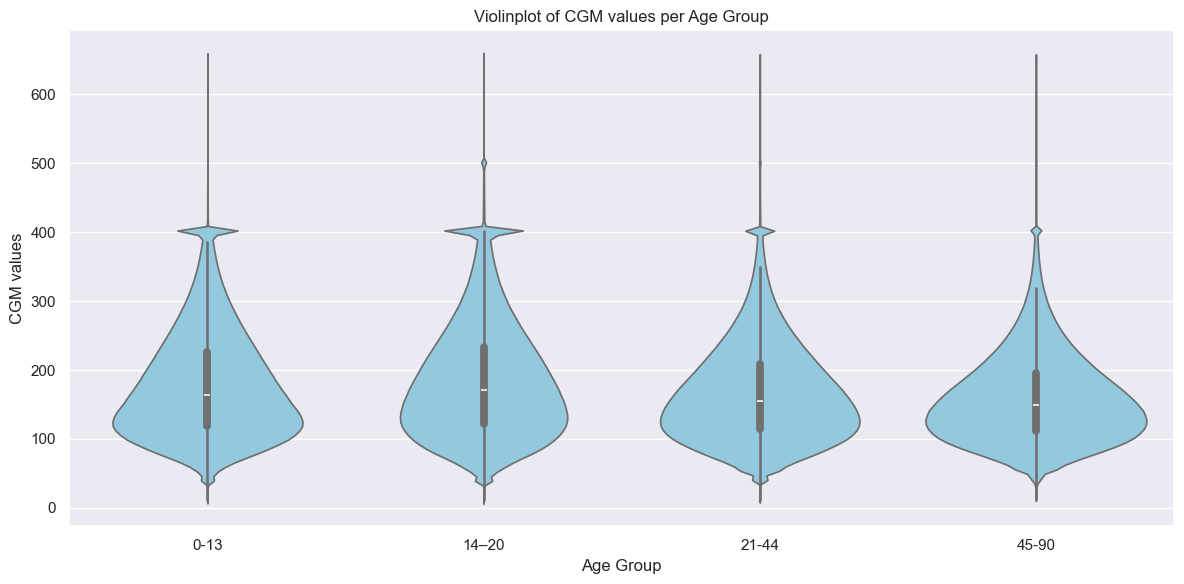

In [ ]:
# Violinplots per age group
combined_df_v_filtered = df.dropna(subset=["GlucoseCGM"])

sns.set_theme(rc={"figure.figsize": (12, 6)})
sns.violinplot(x="AgeGroup5", y="GlucoseCGM", data=combined_df_v_filtered, color="skyblue")
plt.title("Violinplot of CGM values per Age Group")
plt.xlabel("Age Group")
plt.ylabel("CGM values")

plt.tight_layout()
plt.show()

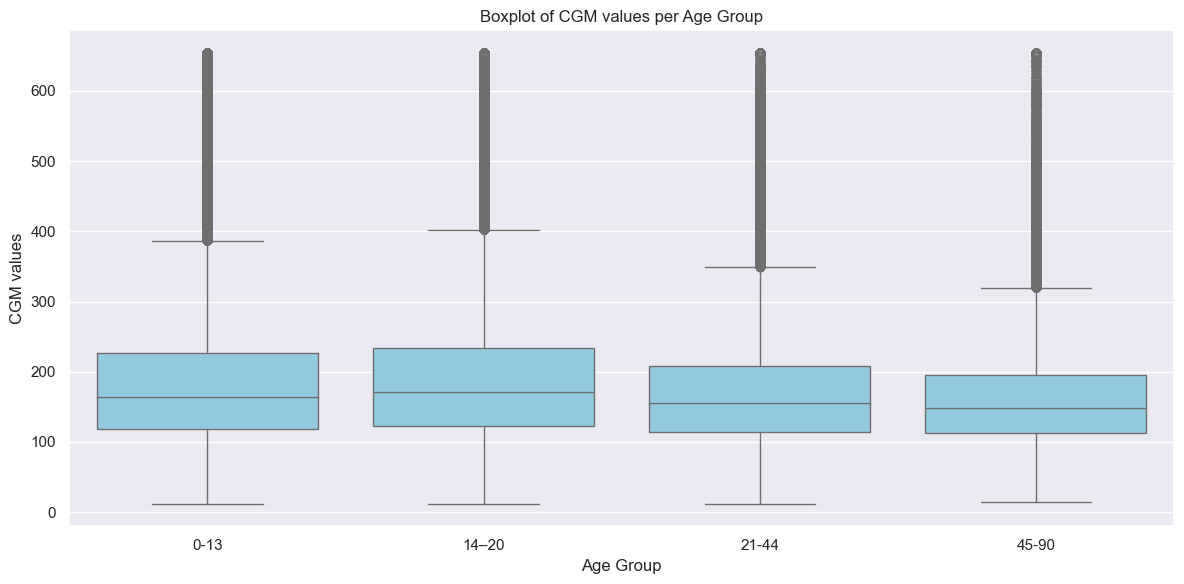

In [ ]:
# Boxplots per age group
sns.set_theme(rc={"figure.figsize": (12, 6)})
sns.boxplot(x="AgeGroup5", y="GlucoseCGM", data=combined_df_v_filtered, color="skyblue")
plt.title("Boxplot of CGM values per Age Group")
plt.xlabel("Age Group")
plt.ylabel("CGM values")

plt.tight_layout()
plt.show()